In [1]:
%load_ext autoreload
%autoreload 2
from black_scholes import call,put,parity_check 
print(call(100,100,1,0.05,0,0.20))
print(put(100,100,1,0.05,0,0.20))
print(parity_check(call(100,100,1,0.05,0,0.20),put(100,100,1,0.05,0,0.20),100,100,1,0.05,0))


10.450583572185565
5.573526022256971
(np.float64(4.877057549928594), np.float64(4.877057549928594))


Text(0, 0.5, 'Option price')

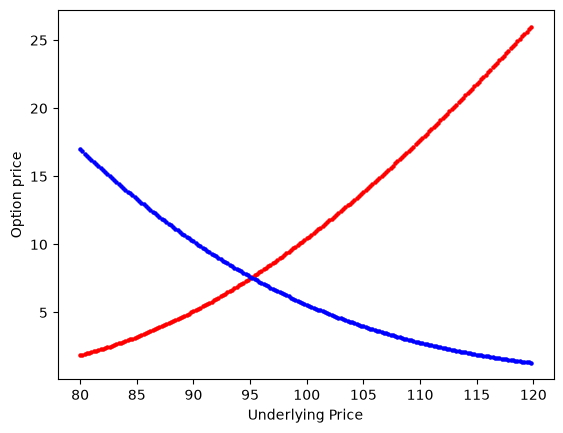

In [10]:
import matplotlib.pyplot as plt
x=[(i*10+4000)/50 for i in range(200)]
y=[call(t,100,1,0.05,0,0.20) for t in x]
yp=[put(t,100,1,0.05,0,0.20) for t in x]
fig, ax = plt.subplots()
ax.scatter(x, y, s=5, c="r")
ax.scatter(x, yp, s=5, c="b")
ax.set_xlabel("Underlying Price")
ax.set_ylabel("Option price")

0.6368306511756191


Text(0, 0.5, 'Option price')

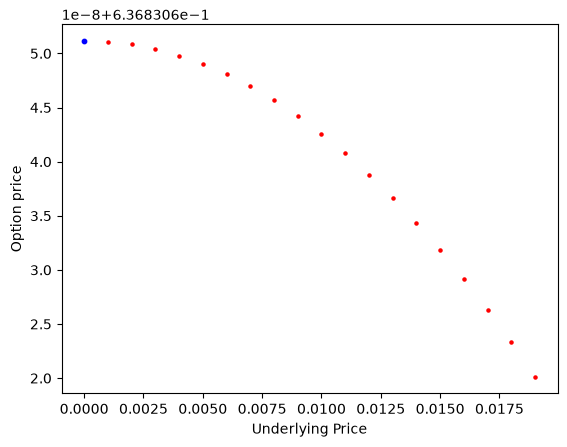

In [9]:
from black_scholes import greeks_op, greeks_val,call,put
delta_c = greeks_op(100,100,1,0.05,0,0.20)["delta_c"]
print(delta_c)
x= [i/1000 for i in range(0,20)]
y= [greeks_val(100,100,1,0.05,0,0.20,i,call)["delta"] for i in x]
fig, ax = plt.subplots()

ax.scatter(0,delta_c,s=10, c="b")
ax.scatter(x, y, s=5, c="r")


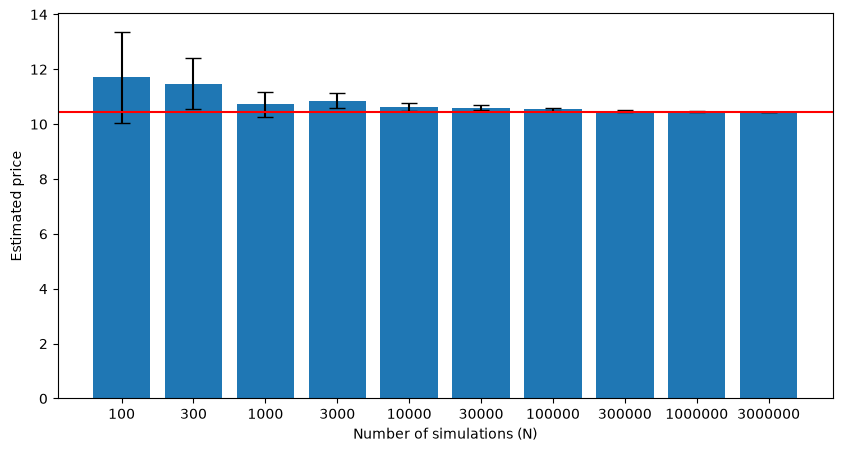

In [1]:
from monte_carlo import monte_carlo
from black_scholes import call,put,parity_check
import matplotlib.pyplot as plt
x = [v for i in range(0, 5) for v in (10**(2+i), 3*10**(2+i))]
results=[monte_carlo(100,100,1,0.05,0,0.20,i,32) for i in x]
y=[results[i]["m_c"] for i in range(len(x))]
c= [results[i]["std_err_c"] for i in range(len(x))] 
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.bar(range(len(x)), y, tick_label=x)
plt.errorbar(range(len(x)), y, yerr=c, fmt='none', color='black', capsize=6)
plt.axhline(y=call(100,100,1,0.05,0,0.20), color='r', linestyle='-')
plt.xlabel("Number of simulations (N)")
plt.ylabel("Estimated price")
plt.show()

In [ ]:
#comparison
from monte_carlo import monte_carlo_anti,monte_carlo
import matplotlib.pyplot as plt
import numpy as np
x=np.random.randint(0,50,100)
trial=np.arange(len(x))
y=[monte_carlo(100,100,1,0.05,0,0.20,300000,i)["std_err_c"] for i in x]
y_anti=[monte_carlo_anti(100,100,1,0.05,0,0.20,300000,i)["std_err_c"] for i in x]
fig,ax=plt.subplots()
ax.scatter(trial, y, s=5, c="r")
ax.scatter(trial, y_anti, s=5, c="b")
ax.set_xlabel("Trial")
ax.set_ylabel("Std error (call)")
plt.show()

In [1]:
import sys
print(sys.executable)

D:\New folder\pricer\.venv\Scripts\python.exe
